In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../Snowflake Notebooks Package/data/data_join.csv")
df.head(5)

,LATITUDE,LONGITUDE,DATE,TOTALAL_KALINITY,ELECTRICAL_CONDUCTANCE,DISSOLVED_REACTIVE_PHOSPHORUS,PET,NIR,GREEN,SWIR16,SWIR22,NDMI,MNDWI
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,174.2,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,124.1,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,127.5,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,129.7,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,129.2,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683


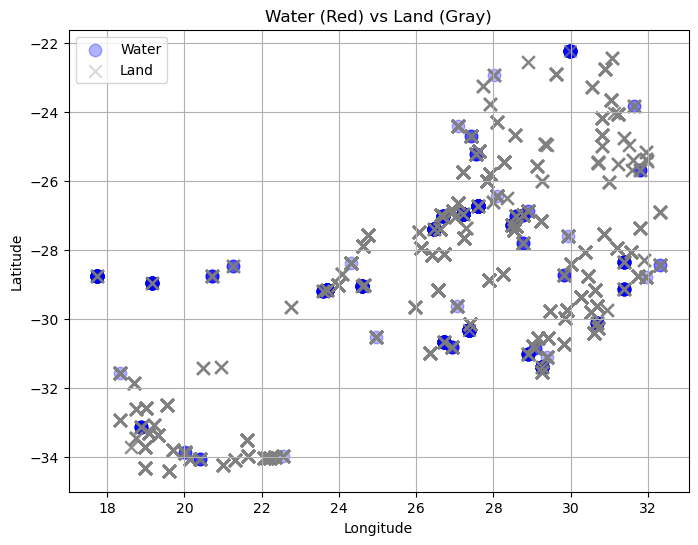

In [3]:
import matplotlib.pyplot as plt

df["water"] = df["MNDWI"] > 0

plt.figure(figsize=(8,6))

water = df[df["water"] == True]
plt.scatter(
    water["LONGITUDE"],
    water["LATITUDE"],
    c="blue",
    marker='o',
    s=80,
    alpha=0.3,
    label="Water"
)

land = df[df["water"] == False]
plt.scatter(
    land["LONGITUDE"],
    land["LATITUDE"],
    c="gray",
    marker='x',
    s=80,
    alpha=0.3,
    label="Land"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Water (Red) vs Land (Gray)")
plt.legend()
plt.grid()
plt.show()

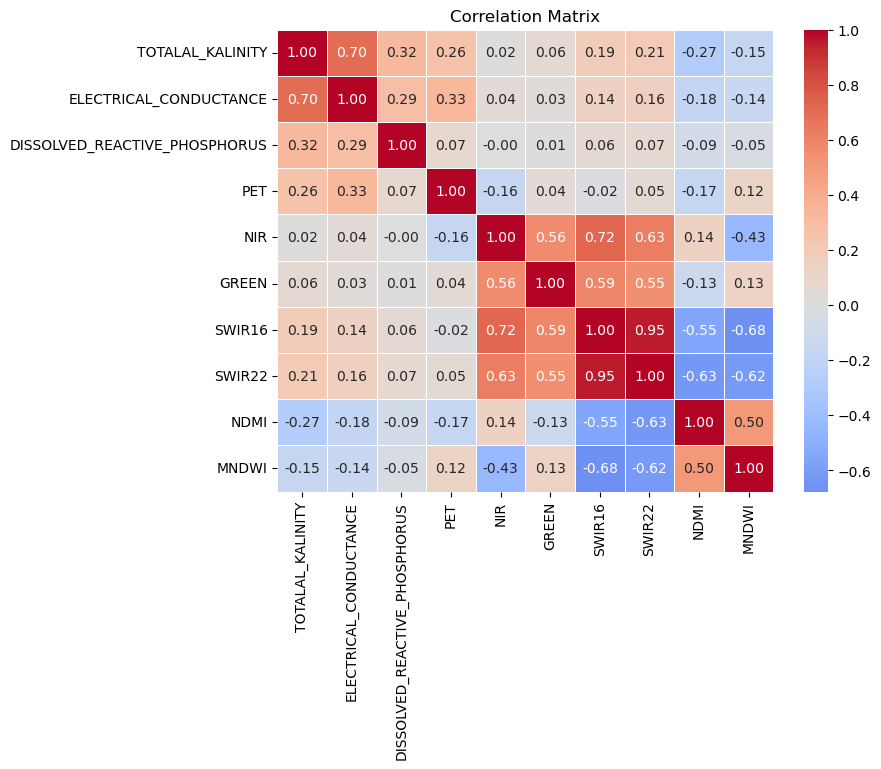

In [4]:
import seaborn as sns

corr_df = df[["TOTALAL_KALINITY", "ELECTRICAL_CONDUCTANCE", "DISSOLVED_REACTIVE_PHOSPHORUS", "PET", "NIR", "GREEN", "SWIR16", "SWIR22", "NDMI", "MNDWI"]].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.7)
plt.title("Correlation Matrix")
plt.show()  

In [5]:
#Feature engineering
df["water_moisture_index"] = df["NDMI"] * df["MNDWI"]
df["evaporation_stress"] = df["PET"] / (df["NDMI"] + 1e-6)
df["SWIR_ratio"] = df["SWIR16"] / (df["SWIR22"] + 1e-6)
df["SWIR_diff"] = df["SWIR16"] - df["SWIR22"]
df["is_water"] = df["MNDWI"] > 0

# Weather feature
df["DATE"] = pd.to_datetime(df["DATE"], format='%d-%m-%Y')
df["month"] = df["DATE"].dt.month
df["year"] = df["DATE"].dt.year
df["dayofyear"] = df["DATE"].dt.dayofyear

# Date feature
df["month_sin"] = np.sin(2 * np.pi * df["month"]/12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]/12)
df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"]/365)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"]/365)

# log transform (skewed target)
df["DRP_log"] = np.log1p(df["DISSOLVED_REACTIVE_PHOSPHORUS"])
df["TOTALAL_log"] = np.log1p(df["TOTALAL_KALINITY"])
df["EC_log"] = np.log1p(df["ELECTRICAL_CONDUCTANCE"])

In [6]:
df.columns

Index(['LATITUDE', 'LONGITUDE', 'DATE', 'TOTALAL_KALINITY',
       'ELECTRICAL_CONDUCTANCE', 'DISSOLVED_REACTIVE_PHOSPHORUS', 'PET', 'NIR',
       'GREEN', 'SWIR16', 'SWIR22', 'NDMI', 'MNDWI', 'water',
       'water_moisture_index', 'evaporation_stress', 'SWIR_ratio', 'SWIR_diff',
       'is_water', 'month', 'year', 'dayofyear', 'month_sin', 'month_cos',
       'dayofyear_sin', 'dayofyear_cos', 'DRP_log', 'TOTALAL_log', 'EC_log'],
      dtype='str')

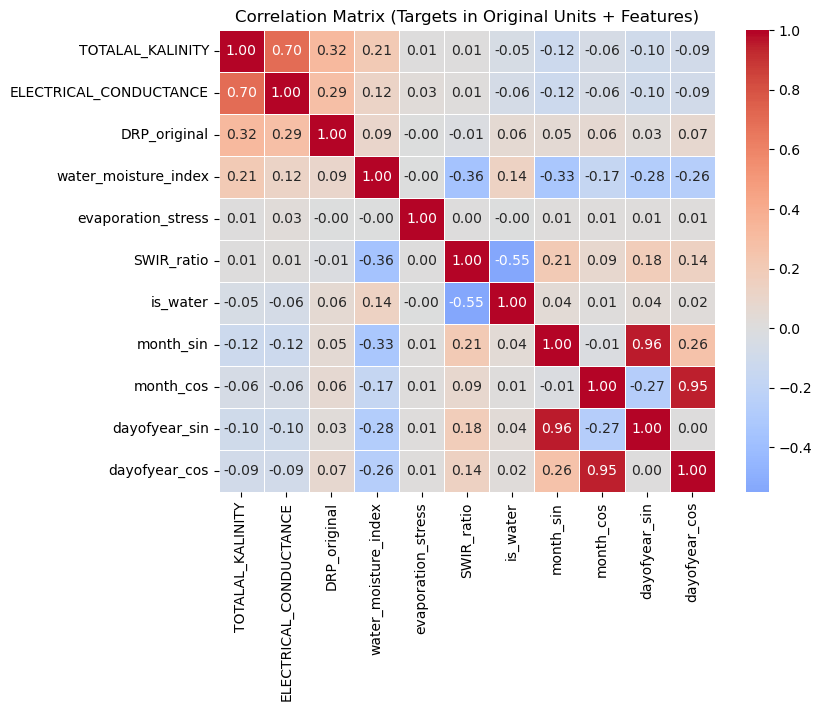

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df["DRP_original"] = np.expm1(df["DRP_log"])

corr_df = df[[ 
    'TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE', 
    'DRP_original',               
    'water_moisture_index', 
    'evaporation_stress', 
    'SWIR_ratio', 
    'is_water',
    'month_sin', 'month_cos',    
    'dayofyear_sin', 'dayofyear_cos'
]].dropna()

corr_matrix_2 = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_2, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.7)
plt.title("Correlation Matrix (Targets in Original Units + Features)")
plt.show()

In [ ]:
# from lightgbm import LGBMRegressor
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_squared_error

# targets = ["TOTALAL_log", "EC_log", "DRP_log"] 
# original_target_map = {
#     "TOTALAL_log": "TOTALAL_KALINITY",
#     "EC_log": "ELECTRICAL_CONDUCTANCE",
#     "DRP_log": "DISSOLVED_REACTIVE_PHOSPHORUS"
# }

# df = df.sort_values("DATE").reset_index(drop=True)
# X = df.drop(columns=targets + ["DATE", "LATITUDE", "LONGITUDE"]) 
# y_dict = {t: df[t].values for t in targets}

# n_splits = 5
# tscv = TimeSeriesSplit(n_splits=n_splits)
# avg_rmse_dict = {}

# for target in targets:
#     y = y_dict[target]
#     rmse_list = []

#     for train_idx, val_idx in tscv.split(X):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_val = y[train_idx], y[val_idx]

#         model = LGBMRegressor(
#             n_estimators=2000,
#             learning_rate=0.03,
#             max_depth=-1,
#             num_leaves=31,
#             subsample=0.8,
#             colsample_bytree=0.8,
#             random_state=42
#         )

#         model.fit(
#             X_train, y_train,
#             eval_set=[(X_val, y_val)],
#             callbacks=[
#                 __import__('lightgbm').early_stopping(50),
#                 __import__('lightgbm').log_evaluation(period=0)
#             ]
#         )

#         last_model = model
#         last_X_val, last_y_val = X_val, y_val

#         y_pred_log = model.predict(X_val)
#         y_pred = np.expm1(y_pred_log)
#         y_true = np.expm1(y_val)

#         rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#         rmse_list.append(rmse)

#     avg_rmse = np.mean(rmse_list)
#     avg_rmse_dict[target] = avg_rmse

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4118
[LightGBM] [Info] Number of data points in the train set: 1554, number of used features: 23
[LightGBM] [Info] Start training from score 4.480918
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l2: 0.00230321
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4336
[LightGBM] [Info] Number of data points in the train set: 3107, number of used features: 24
[LightGBM] [Info] Start training from score 4.513720
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1878]	valid_0's 

In [9]:
df[['TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE',
    'DISSOLVED_REACTIVE_PHOSPHORUS']].describe()

,TOTALAL_KALINITY,ELECTRICAL_CONDUCTANCE,DISSOLVED_REACTIVE_PHOSPHORUS
count,9319.000000,9319.000000,9319.000000
mean,119.108208,485.004146,43.525338
std,74.692591,341.937736,50.980194
min,4.800000,15.120000,5.000000
25%,55.811000,207.050000,10.000000
50%,113.300000,402.000000,20.000000
75%,170.230000,693.000000,48.000000
max,361.676000,1506.000000,195.000000


In [ ]:
# # =========================
# # Data Leakage & Fold Check
# # =========================

# issues_found = False

# # --- Feature vs Target  ---
# print("=== Feature vs Target Columns Check ===")
# for target in ["TOTALAL_KALINITY", "ELECTRICAL_CONDUCTANCE", "DISSOLVED_REACTIVE_PHOSPHORUS"]:
#     if target in X.columns:
#         print(f"⚠️ issues found: {target} is in feature (likely data leakage)")
#         issues_found = True
#     else:
#         print(f"{target} not in features ✅")
# print()

# # --- TimeSeriesSplit index  ---
# print("=== TimeSeriesSplit index check ===")
# for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
#     overlap = np.intersect1d(train_idx, val_idx)
#     if len(overlap) > 0:
#         print(f"⚠️ Fold {fold}: train/val index overlap ({len(overlap)}) → likely data leakage")
#         issues_found = True
#     else:
#         print(f"Fold {fold}: No overlap ✅")
# print()

# # --- Fold RMSE ---
# print("=== Fold-wise RMSE check ===")
# for target in ["TOTALAL_log", "EC_log", "DRP_log"]:
#     y = y_dict[target]
#     rmse_list = []

#     for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_val = y[train_idx], y[val_idx]

#         model = LGBMRegressor(
#             n_estimators=1000,
#             learning_rate=0.05,
#             max_depth=-1,
#             num_leaves=31,
#             random_state=42
#         )

#         model.fit(
#             X_train, y_train,
#             eval_set=[(X_val, y_val)],
#             callbacks=[
#                 __import__('lightgbm').early_stopping(50),
#                 __import__('lightgbm').log_evaluation(period=0)
#             ]
#         )

#         y_pred_log = model.predict(X_val)
#         if target == "DRP_log":
#             y_pred = np.expm1(y_pred_log)
#             y_true = np.expm1(y_val)
#         else:
#             y_pred = np.expm1(y_pred_log)
#             y_true = np.expm1(y_val)

#         rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#         rmse_list.append(rmse)

#     avg_rmse = np.mean(rmse_list)
#     mean_val = np.mean(y_true)
#     ratio = avg_rmse / mean_val
#     print(f"{target}: Avg RMSE={avg_rmse:.2f}, Mean={mean_val:.2f}, RMSE/Mean={ratio:.2%}")

#     if ratio < 0.05:  
#         print(f"⚠️ Warning: RMSE/Mean is too low → likely data leakage")
#         issues_found = True
# print()

# if not issues_found:
#     print("✅ all checks passed! No obvious data leakage or fold issues detected.")

=== Feature vs Target Columns Check ===
⚠️ issues found: TOTALAL_KALINITY is in feature (likely data leakage)
⚠️ issues found: ELECTRICAL_CONDUCTANCE is in feature (likely data leakage)
⚠️ issues found: DISSOLVED_REACTIVE_PHOSPHORUS is in feature (likely data leakage)

=== TimeSeriesSplit index check ===
Fold 1: No overlap ✅
Fold 2: No overlap ✅
Fold 3: No overlap ✅
Fold 4: No overlap ✅
Fold 5: No overlap ✅

=== Fold-wise RMSE check ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4118
[LightGBM] [Info] Number of data points in the train set: 1554, number of used features: 23
[LightGBM] [Info] Start training from score 4.480918
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[133]	valid_0's l2: 0.000128221
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.00

In [11]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

targets = [
    'TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE',
    'DISSOLVED_REACTIVE_PHOSPHORUS'
]

df = df.sort_values("DATE").reset_index(drop=True)

df["DRP_log"] = np.log1p(df["DISSOLVED_REACTIVE_PHOSPHORUS"])

X = df.drop(columns=targets + ['DATE'])
y_dict = {
    'TOTALAL_KALINITY': df['TOTALAL_KALINITY'].values,
    'ELECTRICAL_CONDUCTANCE': df['ELECTRICAL_CONDUCTANCE'].values,
    'DRP_log': df['DRP_log'].values
}

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

avg_rmse_dict = {}
avg_r2_dict = {}

for target in y_dict.keys():
    y = y_dict[target]
    rmse_list = []
    r2_list = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            random_state=42
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                __import__('lightgbm').early_stopping(50),
                __import__('lightgbm').log_evaluation(period=0)
            ]
        )

        y_pred = model.predict(X_val)

        if target == "DRP_log":
            y_pred = np.expm1(y_pred)
            y_val = np.expm1(y_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)

        r2 = r2_score(y_val, y_pred)
        r2_list.append(r2)

    avg_rmse_dict[target] = np.mean(rmse_list)
    avg_r2_dict[target] = np.mean(r2_list)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4397
[LightGBM] [Info] Number of data points in the train set: 1554, number of used features: 25
[LightGBM] [Info] Start training from score 117.344663
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[123]	valid_0's l2: 5.4557
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4641
[LightGBM] [Info] Number of data points in the train set: 3107, number of used features: 26
[LightGBM] [Info] Start training from score 120.925829
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[165]	valid_0's l2: 0.505786
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the over

In [12]:
print("\n=== RMSE / Mean Ratio ===")
for target, rmse in avg_rmse_dict.items():
    mean_val = df[target].mean()
    ratio = rmse / mean_val
    print(f"{target}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Mean: {mean_val:.4f}")
    print(f"  RMSE/Mean: {ratio:.2%}\n")

print("\n=== R^2 / Mean Ratio ===")
for target, r2 in avg_r2_dict.items():
    mean_val = df[target].mean()
    ratio = r2 / mean_val
    print(f"{target}")
    print(f"  R^2: {r2:.4f}")


=== RMSE / Mean Ratio ===
TOTALAL_KALINITY
  RMSE: 1.0600
  Mean: 119.1082
  RMSE/Mean: 0.89%

ELECTRICAL_CONDUCTANCE
  RMSE: 3.7108
  Mean: 485.0041
  RMSE/Mean: 0.77%

DRP_log
  RMSE: 0.4323
  Mean: 3.2990
  RMSE/Mean: 13.11%


=== R^2 / Mean Ratio ===
TOTALAL_KALINITY
  R^2: 0.9997
ELECTRICAL_CONDUCTANCE
  R^2: 0.9999
DRP_log
  R^2: 0.9999


In [13]:
targets = [
    'TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE',
    'DISSOLVED_REACTIVE_PHOSPHORUS'
]

feature_cols = df.drop(columns=targets + ['DATE']).columns
print("=== Feature vs Target Columns Check ===")
for t in targets:
    if t in feature_cols:
        print(f"⚠️ issues: {t}is in feature (likely data leakage)")
    else:
        print(f"{t}: no issues ✅")

from sklearn.model_selection import TimeSeriesSplit

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print("\n=== TimeSeriesSplit index check ===")
for fold, (train_idx, val_idx) in enumerate(tscv.split(df)):
    overlap = np.intersect1d(train_idx, val_idx)
    if len(overlap) > 0:
        print(f"Fold {fold+1}: overlap ⚠️")
    else:
        print(f"Fold {fold+1}: No overlap ✅")

=== Feature vs Target Columns Check ===
TOTALAL_KALINITY: no issues ✅
ELECTRICAL_CONDUCTANCE: no issues ✅
DISSOLVED_REACTIVE_PHOSPHORUS: no issues ✅

=== TimeSeriesSplit index check ===
Fold 1: No overlap ✅
Fold 2: No overlap ✅
Fold 3: No overlap ✅
Fold 4: No overlap ✅
Fold 5: No overlap ✅
